# Primary model interpretation

This notebook interprets the selected primary model saved by `scripts/16_train_baseline_models.py`. It uses SHAP values to explain which inputs drive its predictions.

It examines:

1. reproduction of the saved test predictions;
2. construction of a balanced SHAP sample;
3. global feature importance;
4. direction and heterogeneity of feature effects;
5. effects of the three leading predictors; and
6. stability of feature importance across test quarters.

The analysis describes predictive associations inside the fitted model. It does not establish causal effects, retrain the model, or alter the feature set.

## 1. Load the selected model and reproduce its predictions

The saved preprocessing parameters are applied exactly as they were during training. Reproducing the stored test predictions verifies that the interpretation is attached to the correct fitted model.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap


project_root = Path.cwd().resolve()

while not (project_root / 'config' / 'paths.yaml').is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError('Could not locate the project root.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config, get_project_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


paths = get_paths_config()
project = get_project_config()
model_path = paths.models / 'baseline' / 'selected_baseline_model.joblib'
sample_path = paths.processed / 'modeling' / 'modeling_sample.parquet'
predictions_path = (
    paths.tables / 'modeling' / 'selected_baseline_test_predictions.parquet'
)

for description, path in {
    'selected model': model_path,
    'modeling sample': sample_path,
    'test predictions': predictions_path,
}.items():
    if not path.is_file():
        raise FileNotFoundError(f'{description} not found: {path}')

bundle = joblib.load(model_path)
model_name = bundle['model_name']
model = bundle['model']
features = tuple(bundle['features'])
preprocessing = bundle['preprocessing']

if not model_name.startswith('xgboost'):
    raise RuntimeError('SHAP interpretation currently expects a selected XGBoost model.')

display_names = {
    'market_cap_usd': 'Log market capitalization',
    'average_daily_dollar_volume_63d': 'Log dollar volume',
    'return_21d': 'Return (21 days)',
    'momentum_252_21d': 'Momentum (252–21 days)',
    'volatility_63d': 'Volatility (63 days)',
    'downside_volatility_63d': 'Downside volatility (63 days)',
    'market_beta_252d': 'Market beta (252 days)',
    'maximum_drawdown_252d': 'Maximum drawdown (252 days)',
    'negative_return_share_63d': 'Negative-return share (63 days)',
    'reported_ownership_hhi': 'Ownership HHI',
    'mean_owner_portfolio_weight': 'Mean owner portfolio weight',
    'institutional_holder_count_change_percent': 'Holder-count change',
    'total_reported_value_change_percent': 'Reported-value change',
    'reported_ownership_hhi_change': 'Ownership-HHI change',
}
log_features = {
    'market_cap_usd',
    'average_daily_dollar_volume_63d',
    'institutional_holder_count',
    'total_reported_value_usd',
}


def apply_saved_preprocessing(frame, parameters):
    """Apply the transformations stored with the selected model."""
    feature_names = tuple(parameters['features'])
    transformed = frame.loc[:, feature_names].astype(float).copy()

    for feature in log_features.intersection(feature_names):
        transformed[feature] = np.log1p(transformed[feature])

    transformed = transformed.clip(
        lower=parameters['lower'],
        upper=parameters['upper'],
        axis='columns',
    ).fillna(parameters['medians'])

    if parameters['means'] is not None:
        transformed = (
            transformed - parameters['means']
        ) / parameters['standard_deviations']

    transformed.columns = [display_names[name] for name in feature_names]
    return transformed


sample_columns = [
    'report_period',
    'information_date',
    'permno',
    'sample_split',
    *features,
]
test = pd.read_parquet(sample_path, columns=sample_columns)
test = test.loc[test['sample_split'].eq('test')].drop(columns='sample_split')
saved_predictions = pd.read_parquet(
    predictions_path,
    columns=[
        'report_period',
        'information_date',
        'permno',
        'predicted_future_max_drawdown_63d',
    ],
)
test = test.merge(
    saved_predictions,
    on=['report_period', 'information_date', 'permno'],
    how='left',
    validate='one_to_one',
)

all_model_features = apply_saved_preprocessing(test, preprocessing)
reproduced_predictions = np.clip(
    model.predict(all_model_features.to_numpy()),
    0,
    1,
)
maximum_prediction_difference = np.max(
    np.abs(
        reproduced_predictions
        - test['predicted_future_max_drawdown_63d'].to_numpy()
    )
)

if maximum_prediction_difference > 1e-6:
    raise RuntimeError('The saved test predictions could not be reproduced.')

set_matplotlib_style()

print(f'Selected model: {model_name}')
print(f'Model features: {len(features):,}')
print(f'Test observations: {len(test):,}')
print(f'Maximum prediction difference: {maximum_prediction_difference:.2e}')

Selected model: xgboost_augmented
Model features: 12
Test observations: 30,511
Maximum prediction difference: 0.00e+00


## 2. SHAP interpretation sample

SHAP values are computed for a reproducible sample of 625 observations from each of the eight test quarters. Equal sampling prevents larger quarters from receiving greater weight in the global interpretation.

In [2]:
interpretation_sample = (
    test.groupby('report_period', group_keys=False, sort=True)
    .sample(n=625, random_state=project.seed)
    .sort_values(['report_period', 'permno'])
    .reset_index(drop=True)
)
model_features = apply_saved_preprocessing(
    interpretation_sample,
    preprocessing,
)

explainer = shap.TreeExplainer(model)
shap_values = explainer(model_features)
reconstructed = (
    np.asarray(shap_values.base_values)
    + np.asarray(shap_values.values).sum(axis=1)
)
shap_difference = np.max(
    np.abs(reconstructed - model.predict(model_features.to_numpy()))
)

if shap_difference > 1e-5:
    raise RuntimeError('SHAP values do not reconstruct the model predictions.')

print(f'Interpretation observations: {len(interpretation_sample):,}')
print(
    'Observations per quarter: '
    f'{interpretation_sample.groupby("report_period").size().min():,}'
)
print(f'Maximum SHAP reconstruction difference: {shap_difference:.2e}')

Interpretation observations: 5,000
Observations per quarter: 625
Maximum SHAP reconstruction difference: 4.77e-07


## 3. Global feature importance

Mean absolute SHAP values measure how strongly each feature changes predictions on average. They measure influence, not direction.

,feature,mean_absolute_shap,importance_share
0,Downside volatility (63 days),0.0486,38.50%
1,Maximum drawdown (252 days),0.0321,25.40%
2,Log market capitalization,0.0100,7.92%
3,Momentum (252–21 days),0.0072,5.72%
4,Market beta (252 days),0.0068,5.41%
5,Ownership HHI,0.0060,4.73%
6,Return (21 days),0.0057,4.53%
7,Holder-count change,0.0039,3.06%
8,Mean owner portfolio weight,0.0033,2.63%
9,Ownership-HHI change,0.0012,0.92%


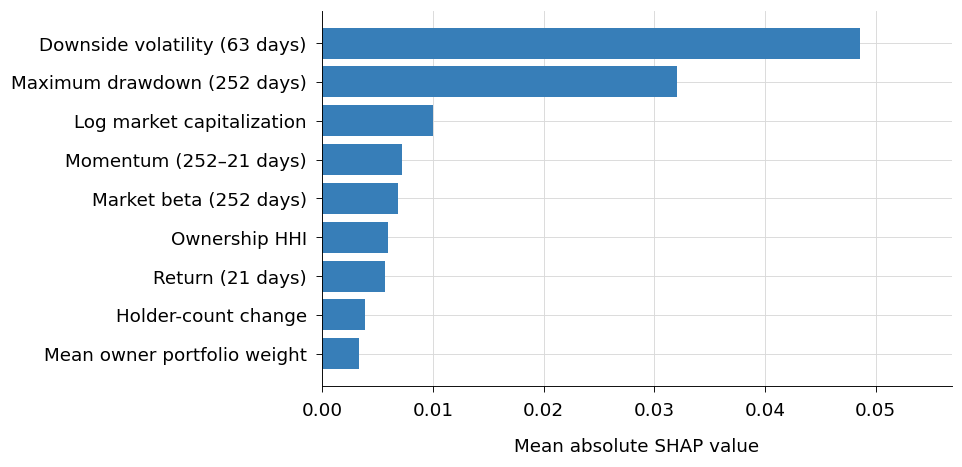

In [3]:
shap_importance = pd.DataFrame(
    {
        'feature': model_features.columns,
        'mean_absolute_shap': np.abs(shap_values.values).mean(axis=0),
    }
)
shap_importance['importance_share'] = (
    shap_importance['mean_absolute_shap']
    / shap_importance['mean_absolute_shap'].sum()
)
shap_importance = shap_importance.sort_values(
    'mean_absolute_shap',
    ascending=False,
).reset_index(drop=True)

display(
    shap_importance.style.format(
        {
            'mean_absolute_shap': '{:.4f}',
            'importance_share': '{:.2%}',
        }
    )
)

plot_data = (
    shap_importance
    .head(9)
    .sort_values("mean_absolute_shap")
)
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
bars = axis.barh(
    plot_data['feature'],
    plot_data['mean_absolute_shap'],
    color=COLOR_PALETTE[0],
)
axis.set_xlabel('Mean absolute SHAP value')
axis.set_ylabel('')
axis.set_xlim(0, plot_data['mean_absolute_shap'].max() * 1.17)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_02_global_shap_importance.pdf")
plt.show()

## 4. Direction and heterogeneity of feature effects

Each point represents one test observation. Its horizontal position is the feature's contribution to predicted drawdown, while color indicates whether the transformed feature value is relatively low or high.

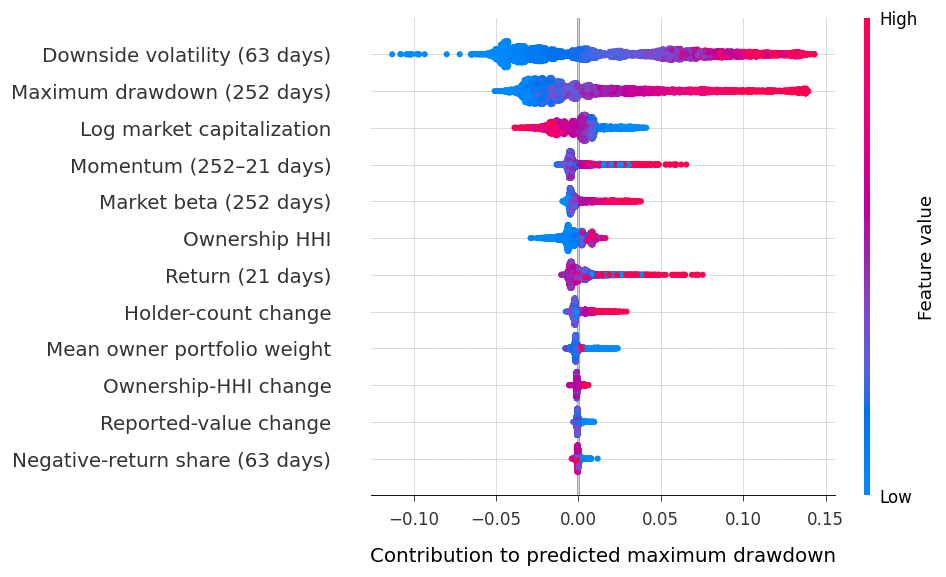

In [4]:
shap.plots.beeswarm(
    shap_values,
    max_display=len(features),
    show=False,
    plot_size=(9, 5.5),
)
figure = plt.gcf()
axis = plt.gca()
axis.set_xlabel('Contribution to predicted maximum drawdown')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_02_shap_beeswarm.pdf")
plt.show()

## 5. Effects of the three leading features

Dependence plots show the transformed feature value against its SHAP contribution. The line connects means across 20 equally sized feature bins and makes the broad nonlinear shape easier to see.

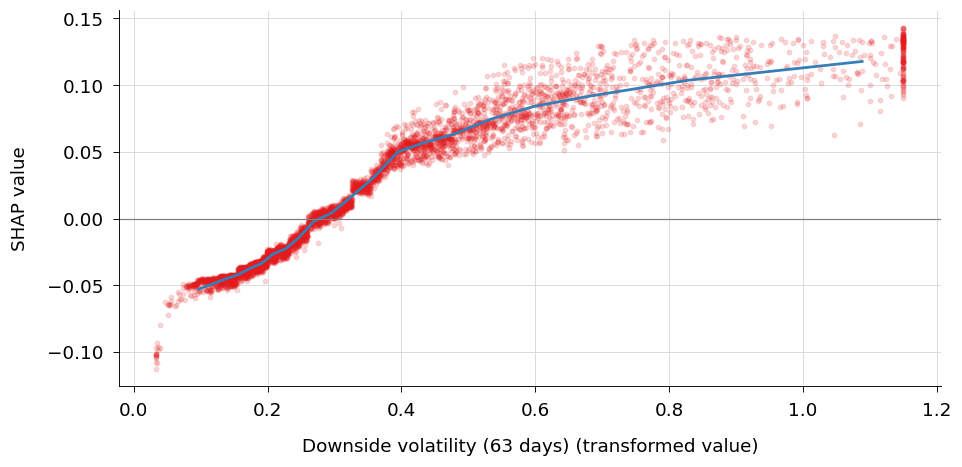

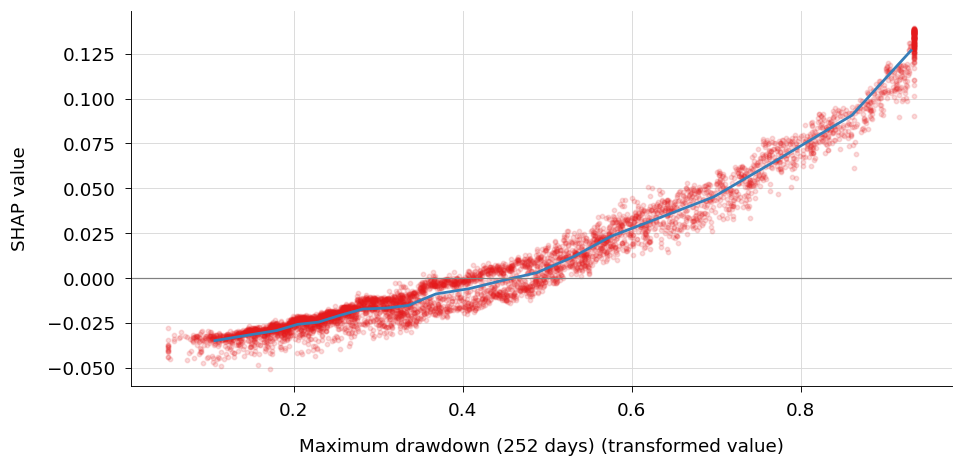

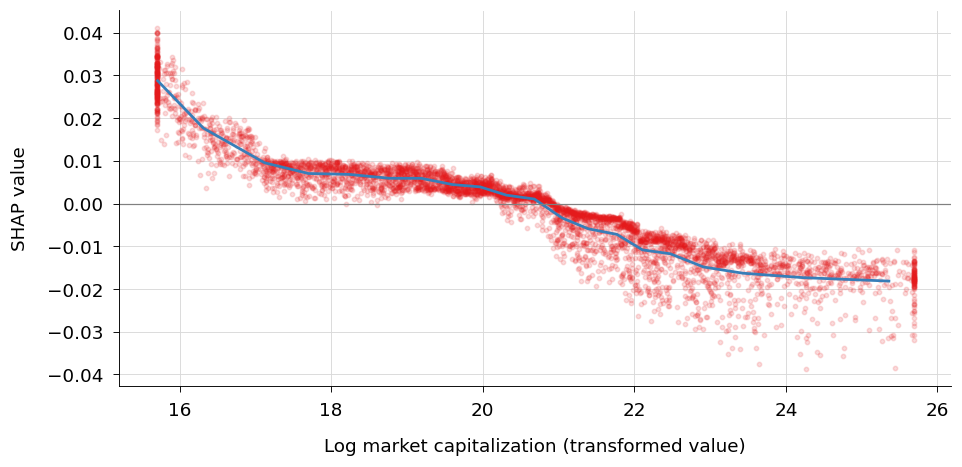

,feature,feature_shap_spearman
0,Downside volatility (63 days),0.989
1,Maximum drawdown (252 days),0.974
2,Log market capitalization,-0.958


In [5]:
top_features = shap_importance.head(3)['feature'].tolist()
direction_rows = []

for rank, feature in enumerate(top_features, start=1):
    feature_index = model_features.columns.get_loc(feature)
    feature_values = model_features[feature]
    feature_shap = pd.Series(shap_values.values[:, feature_index])
    direction_rows.append(
        {
            'feature': feature,
            'feature_shap_spearman': feature_values.corr(
                feature_shap, method='spearman'
            ),
        }
    )

    feature_bin = pd.qcut(
        feature_values.rank(method='first'),
        20,
        labels=False,
    )
    binned_effect = (
        pd.DataFrame(
            {
                'feature_value': feature_values,
                'shap_value': feature_shap,
                'feature_bin': feature_bin,
            }
        )
        .groupby('feature_bin', as_index=False)
        .agg(
            feature_value=('feature_value', 'mean'),
            shap_value=('shap_value', 'mean'),
        )
    )

    figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
    axis.scatter(
        feature_values,
        feature_shap,
        s=8,
        alpha=0.15,
        color=COLOR_PALETTE[1],
    )
    axis.plot(
        binned_effect['feature_value'],
        binned_effect['shap_value'],
        color=COLOR_PALETTE[0],
    )
    axis.axhline(0, color='gray', linewidth=0.8)
    axis.set_xlabel(f'{feature} (transformed value)')
    axis.set_ylabel('SHAP value')
    apply_matplotlib_layout(figure)
    figure.savefig(paths.figures / f'04_02_top_feature_{rank}_dependence.pdf')
    plt.show()

direction_summary = pd.DataFrame(direction_rows)
display(
    direction_summary.style.format({'feature_shap_spearman': '{:.3f}'})
)

## 6. Importance stability across test quarters

Mean absolute SHAP values are converted into importance shares within each test quarter. Stable colors and high rank correlations indicate that the global explanation is not driven by only one period.

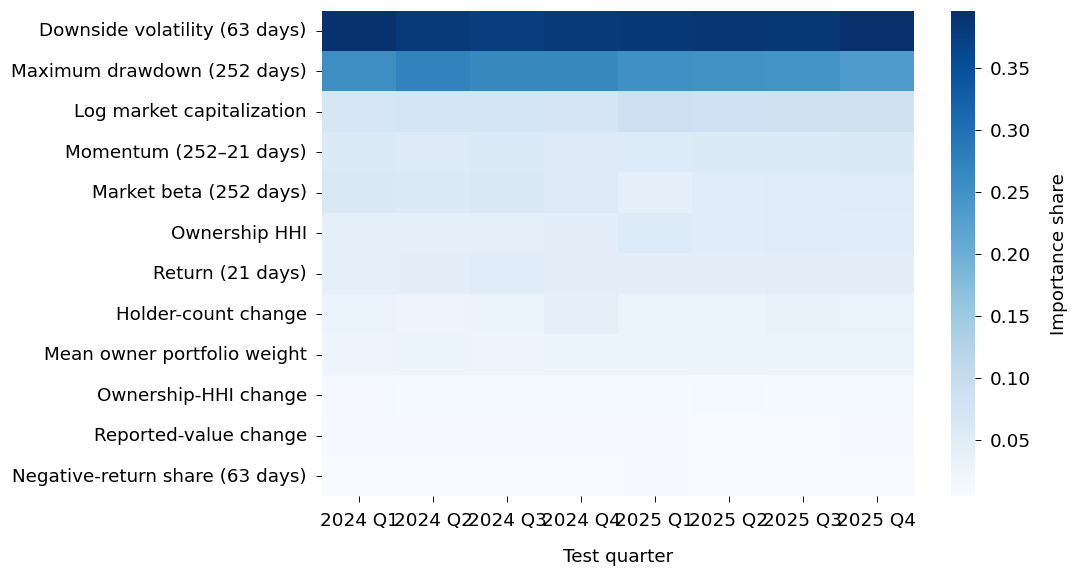

Mean importance-rank correlation: 0.980
Minimum importance-rank correlation: 0.944


In [6]:
absolute_shap = pd.DataFrame(
    np.abs(shap_values.values),
    columns=model_features.columns,
)
absolute_shap['report_period'] = interpretation_sample['report_period']
quarterly_importance = absolute_shap.groupby('report_period').mean()
quarterly_importance_share = quarterly_importance.div(
    quarterly_importance.sum(axis=1),
    axis=0,
)
quarterly_rank_correlations = quarterly_importance_share.T.corr(
    method='spearman'
)
off_diagonal = quarterly_rank_correlations.to_numpy()[
    np.triu_indices(len(quarterly_rank_correlations), k=1)
]
heatmap_data = quarterly_importance_share.loc[
    :, shap_importance['feature']
].T
heatmap_data.columns = [
    f'{date.year} Q{(date.month - 1) // 3 + 1}'
    for date in heatmap_data.columns
]

figure, axis = plt.subplots(figsize=(10, 5.5))
sns.heatmap(
    heatmap_data,
    cmap='Blues',
    cbar_kws={'label': 'Importance share'},
    ax=axis,
)
axis.set_xlabel('Test quarter')
axis.set_ylabel('')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_02_quarterly_shap_importance.pdf")
plt.show()

print(f'Mean importance-rank correlation: {off_diagonal.mean():.3f}')
print(f'Minimum importance-rank correlation: {off_diagonal.min():.3f}')

## 7. Interpretation

- **The interpretation uses the exact tuned model.** Applying the stored preprocessing and model reproduces all 30,511 saved test predictions with a maximum difference of zero. SHAP values reconstruct predictions within `4.77e-07`, confirming numerical consistency.
- **The interpretation sample is balanced over time.** It contains 5,000 observations—625 from each of the eight test quarters—so no quarter dominates the global explanation merely because it contains more securities.
- **Historical risk measures remain dominant.** Downside volatility contributes 38.50% of total mean absolute SHAP importance and past maximum drawdown contributes 25.40%. Market capitalization ranks third at 7.92%; the five retained ownership variables together contribute a smaller share.
- **The leading effects have coherent directions.** Higher downside volatility and larger past drawdowns raise predicted forward drawdown, whereas larger market capitalization lowers it. Their feature-SHAP Spearman correlations are 0.989, 0.974, and -0.958, respectively.
- **Ownership information is used, but it is secondary.** Ownership HHI is the most important retained ownership variable at 4.73% of global SHAP importance; the remaining ownership variables each contribute less. This is consistent with a small incremental predictive gain rather than a wholesale change in the model's signal.
- **Importance is stable across the test period.** Pairwise correlations between quarterly importance rankings average 0.980 and never fall below 0.944, so the global ordering is not driven by one quarter.
- **SHAP describes the fitted model rather than causal effects.** Importance may be shared among related predictors, and the plots should therefore be read as an explanation of prediction behavior.

The selected augmented model primarily converts recent downside volatility and past drawdown into a forward fragility ranking, with ownership concentration supplying a smaller incremental signal.